# MRI Texture Feature Explorer

Notebook for loading DICOM images and building a clustering-ready texture descriptor using a Gabor filter bank applied directly in k-space (the 2D frequency domain).

## 1. Environment Setup and Library Imports

In [57]:
%pip install pydicom numpy matplotlib scipy scikit-learn --quiet --break-system-packages

Note: you may need to restart the kernel to use updated packages.


In [58]:
import warnings
warnings.filterwarnings("ignore")

import pathlib
import numpy as np
import matplotlib.pyplot as plt
import pydicom
from scipy import ndimage
from sklearn.preprocessing import StandardScaler

# Use the inline backend in VS Code to avoid jupyter-matplotlib widget renderer errors.
get_ipython().run_line_magic("matplotlib", "inline")
_backend = "inline"
plt.close("all")

plt.rcParams.update({
    "figure.facecolor": "#0e0e0e",
    "axes.facecolor": "#0e0e0e",
    "axes.edgecolor": "#555",
    "text.color": "#ddd",
    "xtick.color": "#aaa",
    "ytick.color": "#aaa",
    "axes.titlecolor": "#eee",
    "image.cmap": "gray",
    "figure.dpi": 100,
})

print(f"Matplotlib backend: {_backend}")
print("All libraries loaded successfully.")

Matplotlib backend: inline
All libraries loaded successfully.


## 2. Load DICOM Files from the `MRI/` Folder

In [59]:
MRI_ROOT = pathlib.Path("MRI")

def load_dicom_series(root: pathlib.Path) -> list[pydicom.Dataset]:
    """Recursively find all DICOM files under root, return sorted by slice position."""
    candidates = [p for p in root.rglob("*") if p.is_file() and not p.suffix.lower() in {".inf", ".htm", ".txt", ".cab"}]
    datasets = []
    for path in candidates:
        try:
            ds = pydicom.dcmread(str(path), stop_before_pixels=False)
            if hasattr(ds, "pixel_array"):
                datasets.append(ds)
        except Exception:
            pass
    # Sort by ImagePositionPatient z-coordinate or InstanceNumber fallback
    def sort_key(ds):
        try:
            return float(ds.ImagePositionPatient[2])
        except Exception:
            try:
                return int(ds.InstanceNumber)
            except Exception:
                return 0
    datasets.sort(key=sort_key)
    return datasets


all_series: list[pydicom.Dataset] = load_dicom_series(MRI_ROOT)
print(f"Loaded {len(all_series)} DICOM slices.")
if all_series:
    ds0 = all_series[0]
    print(f"  Modality    : {getattr(ds0, 'Modality', 'N/A')}")
    print(f"  Patient     : {getattr(ds0, 'PatientName', 'N/A')}")
    print(f"  Image size  : {ds0.pixel_array.shape}")
    print(f"  Pixel type  : {ds0.pixel_array.dtype}")

KeyboardInterrupt: 

## 3. Construct 3D Slice Stack

In [ ]:
def apply_modality_lut(ds: pydicom.Dataset) -> np.ndarray:
    """Apply RescaleSlope / RescaleIntercept if present, return float32 array."""
    arr = ds.pixel_array.astype(np.float32)
    slope = float(getattr(ds, "RescaleSlope", 1))
    intercept = float(getattr(ds, "RescaleIntercept", 0))
    return arr * slope + intercept


# Group by shape and keep the largest consistent group
from collections import Counter
shape_counts = Counter(ds.pixel_array.shape for ds in all_series)
dominant_shape = shape_counts.most_common(1)[0][0]
filtered_series = [ds for ds in all_series if ds.pixel_array.shape == dominant_shape]
print(f"Using {len(filtered_series)} slices with shape {dominant_shape} (dropped {len(all_series) - len(filtered_series)} mismatched)")

volume: np.ndarray = np.stack([apply_modality_lut(ds) for ds in filtered_series], axis=0)
print(f"Volume shape : {volume.shape}  (slices × rows × cols)")
print(f"Intensity range : [{volume.min():.1f}, {volume.max():.1f}]")

try:
    pixel_spacing = [float(v) for v in filtered_series[0].PixelSpacing]
except Exception:
    pixel_spacing = [1.0, 1.0]
print(f"Pixel spacing : {pixel_spacing} mm")

Using 1057 slices with shape (512, 512) (dropped 77 mismatched)
Volume shape : (1057, 512, 512)  (slices × rows × cols)
Intensity range : [-3024.0, 2720.0]
Pixel spacing : [0.261719, 0.261719] mm


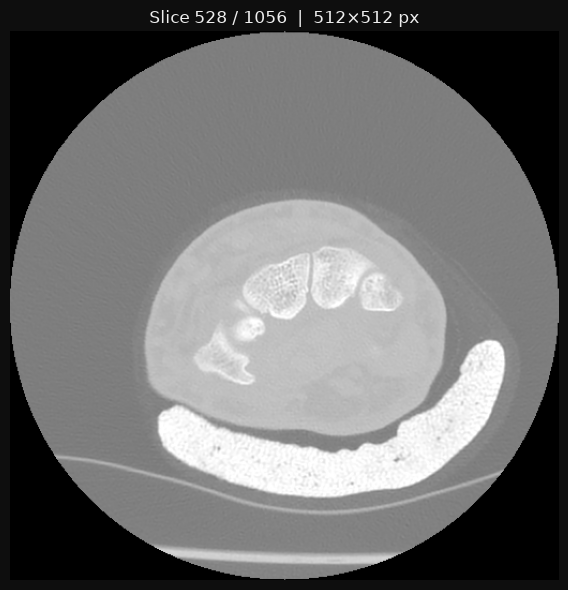

Modality        : CT
Series Desc     : VOLUME PM
Window Center   : 50
Window Width    : 300


In [ ]:
def normalize(arr: np.ndarray, low_pct: float = 1.0, high_pct: float = 99.0) -> np.ndarray:
    lo, hi = np.percentile(arr, [low_pct, high_pct])
    return np.clip((arr - lo) / (hi - lo + 1e-8), 0, 1)


DEFAULT_SLICE = len(volume) // 2
slice_img = volume[DEFAULT_SLICE]

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(normalize(slice_img), cmap="gray", origin="upper")
ax.set_title(f"Slice {DEFAULT_SLICE} / {len(volume) - 1}  |  {slice_img.shape[1]}×{slice_img.shape[0]} px")
ax.axis("off")
plt.tight_layout()
plt.show()

ds_meta = all_series[DEFAULT_SLICE]
print(f"Modality        : {getattr(ds_meta, 'Modality', 'N/A')}")
print(f"Series Desc     : {getattr(ds_meta, 'SeriesDescription', 'N/A')}")
print(f"Window Center   : {getattr(ds_meta, 'WindowCenter', 'N/A')}")
print(f"Window Width    : {getattr(ds_meta, 'WindowWidth', 'N/A')}")

## 4. Compute and Visualize Frequency Domain (2D FFT / k-space)

The 2D FFT maps each spatial frequency component.
- **Low frequencies** (center of the spectrum) map to large-scale contrast & overall brightness.
- **High frequencies** (periphery) map to edges, fine detail, and noise.

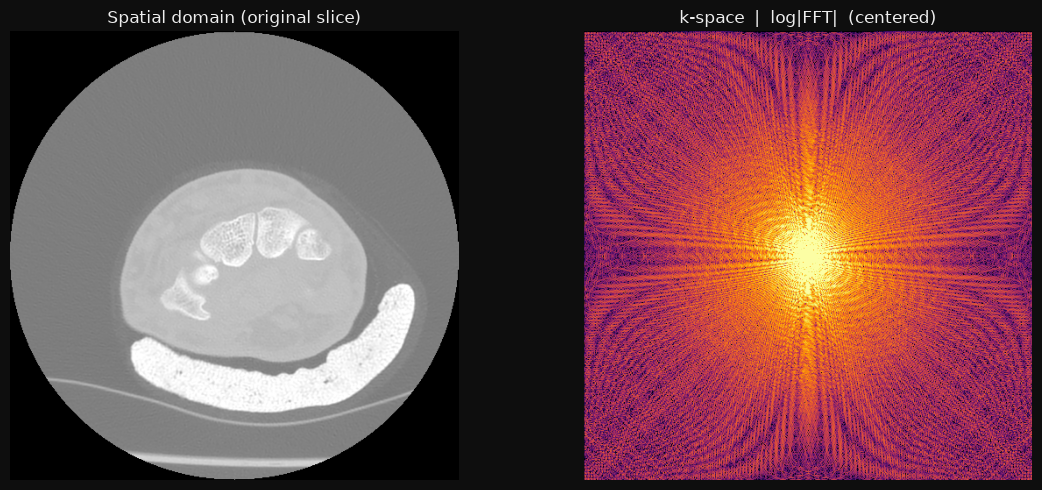

In [ ]:
def compute_kspace(img: np.ndarray) -> np.ndarray:
    """Return centered 2D FFT of img."""
    return np.fft.fftshift(np.fft.fft2(img.astype(np.float64)))


kspace = compute_kspace(slice_img)
log_magnitude = np.log1p(np.abs(kspace))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(normalize(slice_img), cmap="gray")
axes[0].set_title("Spatial domain (original slice)")
axes[0].axis("off")

axes[1].imshow(normalize(log_magnitude), cmap="inferno")
axes[1].set_title("k-space  |  log|FFT|  (centered)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 5. Gabor Filter Bank in k-space (24-D Texture Features)

Each Gabor filter is built directly as a frequency-domain mask (a Gaussian bump centered at a carrier frequency), then applied to the slice's k-space with a single element-wise multiplication before the inverse FFT. This avoids any spatial-domain convolution.

For every one of 3 scales (carrier frequencies) x 4 orientations (0, 45, 90, 135 degrees) we build the classic Gabor **quadrature pair**:
- **Even (cosine-phase)** filter: symmetric Gaussian bumps at `+f0` and `-f0`.
- **Odd (sine-phase)** filter: the same bumps combined with opposite sign (antisymmetric).

Taking the mean response energy of each of the 2 filters gives `3 scales x 4 orientations x 2 filters = 24` features per slice. Features are assembled into a matrix and standardized with `StandardScaler`, so the result is directly usable as input to KMeans, DBSCAN, Gaussian mixtures, hierarchical clustering, etc. **No clustering is performed in this notebook** - only the feature matrix is prepared.

In [ ]:
GABOR_ORIENTATIONS_DEG = [0.0, 45.0, 90.0, 135.0]
GABOR_SCALES = {
    "fine": 0.16,
    "medium": 0.08,
    "coarse": 0.04,
}

GABOR_RADIAL_SIGMA = 0.035    # bandwidth along the carrier direction
GABOR_ANGULAR_SIGMA = 0.035   # bandwidth perpendicular to the carrier direction


def frequency_grid(rows: int, cols: int) -> tuple[np.ndarray, np.ndarray]:
    """Centered (fftshift-ed) frequency coordinates matching compute_kspace's layout."""
    fx = np.fft.fftshift(np.fft.fftfreq(cols)).astype(np.float32)
    fy = np.fft.fftshift(np.fft.fftfreq(rows)).astype(np.float32)
    return np.meshgrid(fx, fy)


def robust_image_scale(img: np.ndarray) -> np.ndarray:
    """Percentile-clip and rescale to [0, 1] so responses are comparable across slices."""
    img_float = img.astype(np.float32)
    low, high = np.percentile(img_float, [1.0, 99.0])
    clipped = np.clip(img_float, low, high)
    return ((clipped - low) / (high - low + 1e-8)).astype(np.float32)


def make_gabor_kspace_pair(
    rows: int,
    cols: int,
    angle_deg: float,
    carrier_frequency: float,
) -> tuple[np.ndarray, np.ndarray]:
    """Build the even/odd (cosine/sine) Gabor filter pair directly as k-space masks.

    A real-valued spatial Gabor filter has a spectrum made of two Gaussian bumps
    placed symmetrically at +carrier_frequency and -carrier_frequency along the
    chosen orientation. The even (cosine phase) filter sums the two bumps; the
    odd (sine phase) filter is their antisymmetric (signed) combination.
    """
    fx, fy = frequency_grid(rows, cols)
    angle = np.deg2rad(angle_deg)

    # Rotate frequency axes: u' is along the carrier direction, v' is perpendicular.
    u = fx * np.cos(angle) + fy * np.sin(angle)
    v = -fx * np.sin(angle) + fy * np.cos(angle)

    bump_plus = np.exp(
        -0.5 * (((u - carrier_frequency) / GABOR_RADIAL_SIGMA) ** 2 + (v / GABOR_ANGULAR_SIGMA) ** 2)
    )
    bump_minus = np.exp(
        -0.5 * (((u + carrier_frequency) / GABOR_RADIAL_SIGMA) ** 2 + (v / GABOR_ANGULAR_SIGMA) ** 2)
    )

    even_filter = (0.5 * (bump_plus + bump_minus)).astype(np.float32)
    odd_filter = (0.5j * (bump_plus - bump_minus)).astype(np.complex64)

    peak = even_filter.max() + 1e-8
    return (even_filter / peak).astype(np.float32), (odd_filter / peak).astype(np.complex64)


def apply_kspace_filter(kspace: np.ndarray, frequency_filter: np.ndarray) -> np.ndarray:
    """Multiply in k-space (frequency domain) and return the spatial-domain response."""
    filtered_kspace = kspace * frequency_filter
    return np.fft.ifft2(np.fft.ifftshift(filtered_kspace)).real


def build_gabor_filter_bank(rows: int, cols: int) -> tuple[list[np.ndarray], list[str]]:
    """3 scales x 4 orientations x (even, odd) = 24 k-space Gabor filters."""
    filters = []
    labels = []

    for scale_name, carrier_frequency in GABOR_SCALES.items():
        for angle_deg in GABOR_ORIENTATIONS_DEG:
            even_filter, odd_filter = make_gabor_kspace_pair(rows, cols, angle_deg, carrier_frequency)
            filters.extend([even_filter, odd_filter])
            labels.extend([
                f"{scale_name}_{angle_deg:g}deg_gabor_even",
                f"{scale_name}_{angle_deg:g}deg_gabor_odd",
            ])

    return filters, labels


def build_texture_vector(img: np.ndarray) -> tuple[np.ndarray, list[str]]:
    """Apply the Gabor k-space filter bank to one slice and return its 24-D feature vector."""
    scaled_img = robust_image_scale(img)
    rows, cols = scaled_img.shape
    filters, labels = build_gabor_filter_bank(rows, cols)
    kspace = compute_kspace(scaled_img)

    vector = [float(np.mean(np.abs(apply_kspace_filter(kspace, gabor_filter)))) for gabor_filter in filters]
    return np.asarray(vector, dtype=np.float32), labels


def build_clustering_feature_matrix(
    image_stack: np.ndarray,
    slice_step: int = 4,
) -> tuple[np.ndarray, np.ndarray, list[str], np.ndarray, StandardScaler]:
    """Build a standardized (n_slices, 24) feature matrix ready for a clustering algorithm.

    No clustering algorithm is fit or run here - only feature extraction + scaling.
    """
    selected_indices = np.arange(0, len(image_stack), slice_step)
    vectors = []
    labels = None

    for slice_index in selected_indices:
        vector, labels = build_texture_vector(image_stack[slice_index])
        vectors.append(vector)

    raw_features = np.nan_to_num(np.vstack(vectors).astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)

    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(raw_features).astype(np.float32)
    scaled_features = np.nan_to_num(scaled_features, nan=0.0, posinf=0.0, neginf=0.0)

    return raw_features, scaled_features, labels, selected_indices, scaler


# Single-slice preview of the 24-D Gabor texture vector.
texture_vector, texture_labels = build_texture_vector(slice_img)
print(f"Single-slice texture vector shape: {texture_vector.shape}")
for label, value in zip(texture_labels, texture_vector):
    print(f"{label:26s} {value:.6f}")

# Clustering-ready feature matrix across the volume (subsampled every 4th slice).
# NOTE: this only prepares features - no clustering algorithm is run here.
texture_features_raw, texture_features_scaled, texture_feature_labels, texture_slice_indices, texture_scaler = (
    build_clustering_feature_matrix(volume, slice_step=4)
)

print(f"\nClustering feature matrix shape: {texture_features_scaled.shape}")
print(f"Slices represented: {texture_slice_indices[0]}..{texture_slice_indices[-1]} (step {texture_slice_indices[1] - texture_slice_indices[0]})")
print("texture_features_scaled is ready to pass into KMeans, DBSCAN, GaussianMixture, AgglomerativeClustering, etc.")

Single-slice texture vector shape: (24,)
fine_0deg_gabor_even       0.001751
fine_0deg_gabor_odd        0.001751
fine_45deg_gabor_even      0.002104
fine_45deg_gabor_odd       0.002103
fine_90deg_gabor_even      0.002675
fine_90deg_gabor_odd       0.002677
fine_135deg_gabor_even     0.002063
fine_135deg_gabor_odd      0.002062
medium_0deg_gabor_even     0.071645
medium_0deg_gabor_odd      0.006918
medium_45deg_gabor_even    0.071955
medium_45deg_gabor_odd     0.008601
medium_90deg_gabor_even    0.071990
medium_90deg_gabor_odd     0.010505
medium_135deg_gabor_even   0.071889
medium_135deg_gabor_odd    0.008187
coarse_0deg_gabor_even     0.451911
coarse_0deg_gabor_odd      0.015155
coarse_45deg_gabor_even    0.452006
coarse_45deg_gabor_odd     0.017780
coarse_90deg_gabor_even    0.451958
coarse_90deg_gabor_odd     0.020157
coarse_135deg_gabor_even   0.452007
coarse_135deg_gabor_odd    0.016912

Clustering feature matrix shape: (265, 24)
Slices represented: 0..1056 (step 4)
texture_featur

## 6. Local Texture Feature Extraction & K-Means Clustering

Extracts 24-D local texture features using the spatial filter bank (Gabor + LoG across 3 scales) and performs unsupervised clustering (K-Means) to segment image regions based on Euclidean distance in the N-dimensional feature space.

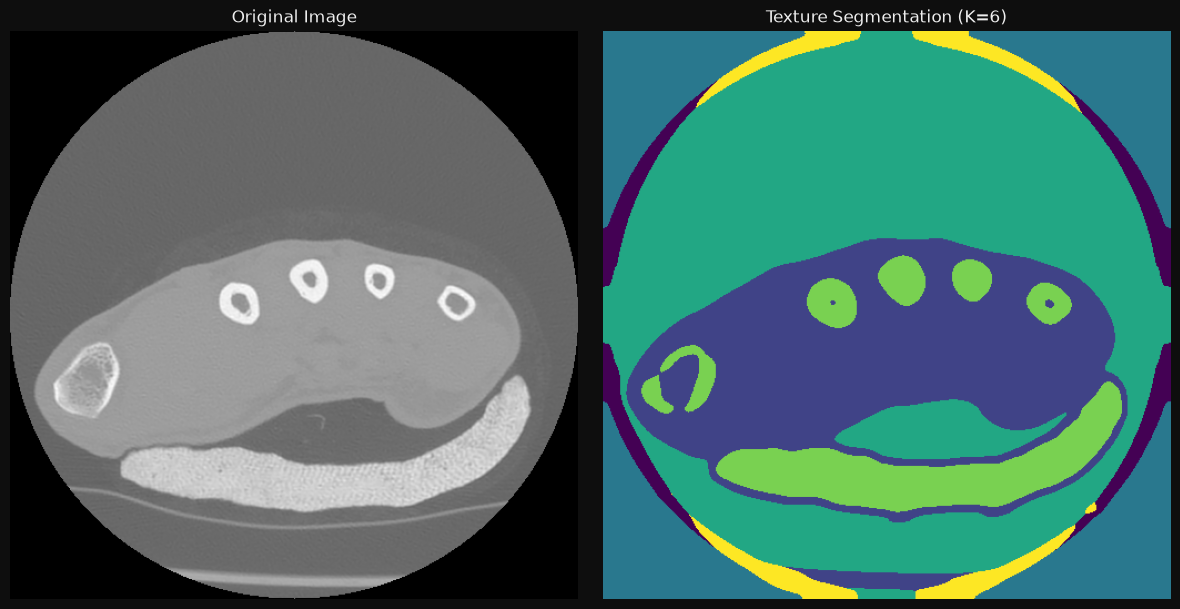

In [69]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Select a single slice and normalize to 8-bit (0-255)
img_original = volume[800]
img_8u = cv2.normalize(img_original, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

# Build the Filter Bank (3 Scales x 8 Filters = 24 Dimensions)
filters = []
escalas = [1.5, 3.0, 4.5]

for scale in escalas:
    # 7 Directional Filters (Gabor)
    for theta in np.arange(0, np.pi, np.pi / 7):
        kern = cv2.getGaborKernel((21, 21), 2.0 * scale, theta, 5.0 * scale, 0.5, 0, ktype=cv2.CV_32F)
        filters.append(kern)
    
    # 1 Circular Filter (Laplacian of Gaussian - LoG)
    gauss_kern = cv2.getGaussianKernel(21, 2.0 * scale)
    gauss_kern_2d = (gauss_kern @ gauss_kern.T).astype(np.float32)
    log_kern = cv2.Laplacian(gauss_kern_2d, cv2.CV_32F)
    filters.append(log_kern)

# Feature Extraction per Pixel (Moving Average Window)
features = []
window_size = 15 # Window size for local mean

for kern in filters:
    # Apply filter to the image
    filtered_img = cv2.filter2D(img_8u, cv2.CV_32F, kern)
    # Calculate magnitude (texture energy)
    magnitude = np.abs(filtered_img)
    # Apply local mean window
    local_mean = cv2.blur(magnitude, (window_size, window_size))
    features.append(local_mean)

# Format and Normalize Data
X_spatial = np.stack(features, axis=-1)
X_vectors = X_spatial.reshape(-1, 24)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vectors)

# K-Means Clustering (OpenCV)
Z = np.float32(X_scaled)
K = 6 # Expected number of texture regions
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
_, label, _ = cv2.kmeans(Z, K, None, criteria, 10, cv2.KMEANS_PP_CENTERS)

# Reshape and Visualize Segmentation
segmentation_map = label.reshape(img_8u.shape)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.imshow(img_8u, cmap="gray")
ax1.set_title("Original Image")
ax1.axis("off")

ax2.imshow(segmentation_map, cmap="viridis")
ax2.set_title(f"Texture Segmentation (K={K})")
ax2.axis("off")

plt.tight_layout()
plt.savefig("exemplo_resultado.jpg", dpi=300, bbox_inches='tight')
plt.show()

## 7. Batch Texture Segmentation & Visualization (Every 50 Slices)

Iterates through the volume at a step of 50 slices, builds the 24-D texture feature vector for each slice using the Gabor and LoG filter bank, scales the features via `StandardScaler`, and applies unsupervised K-Means clustering to segment texture patterns across the dataset.

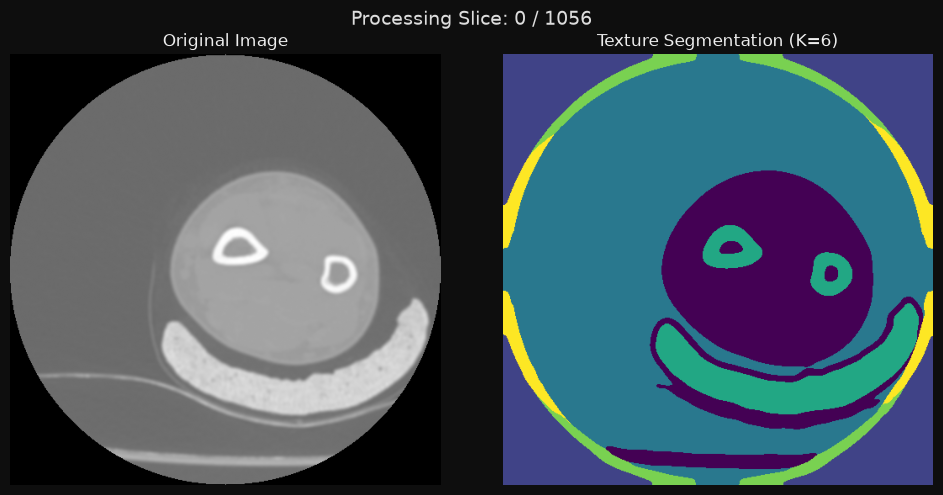

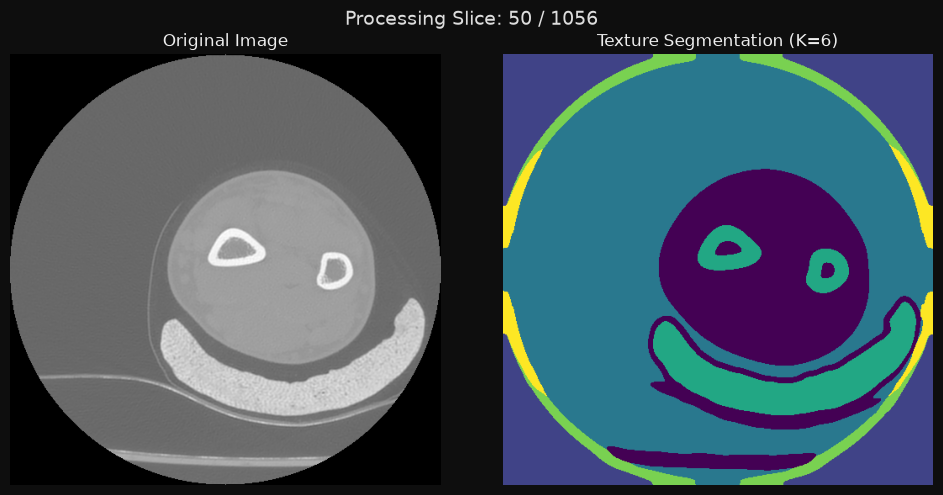

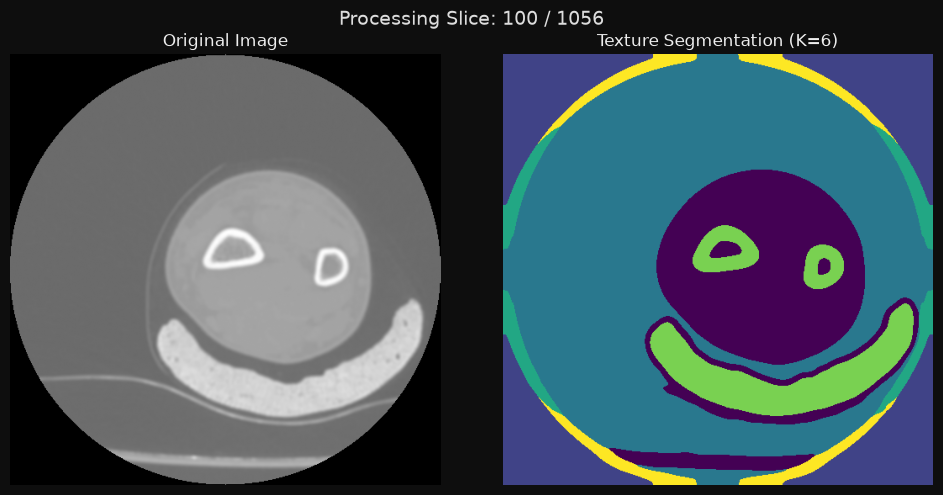

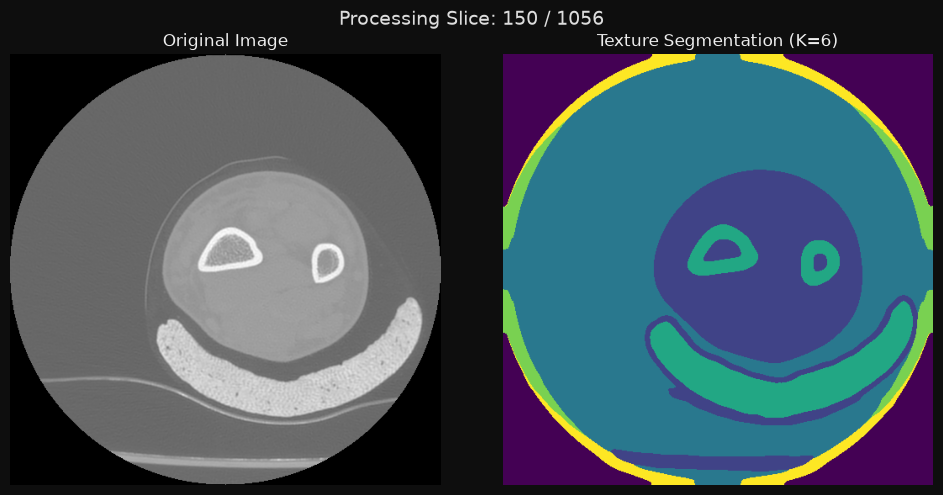

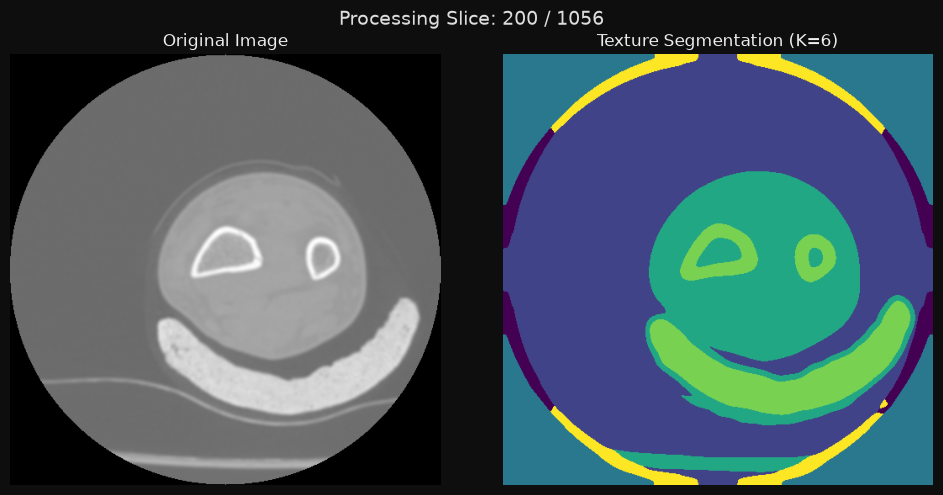

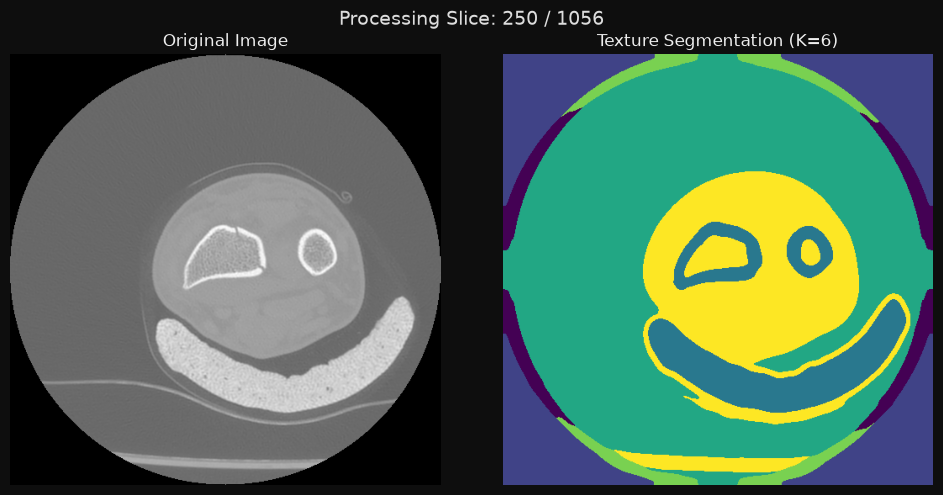

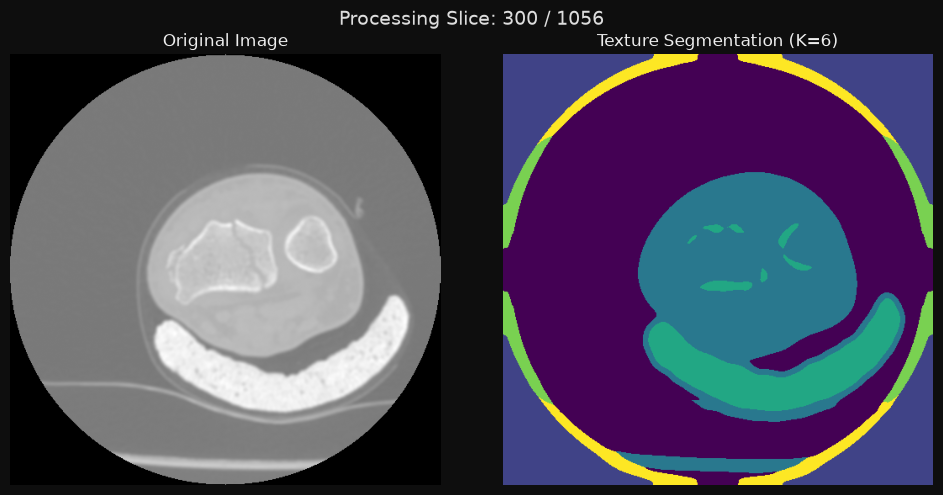

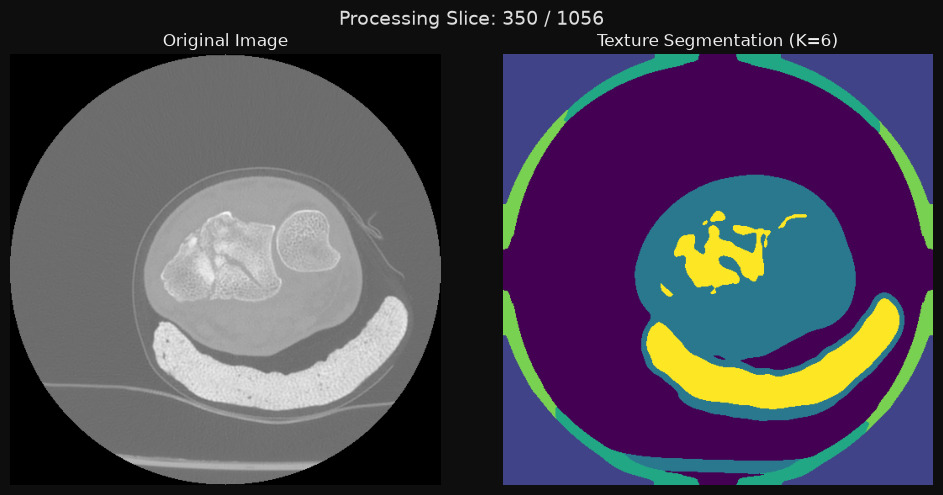

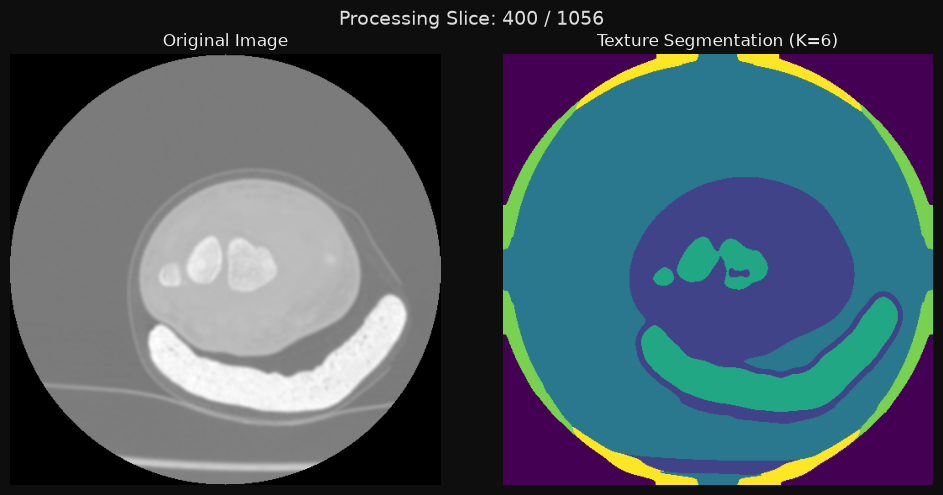

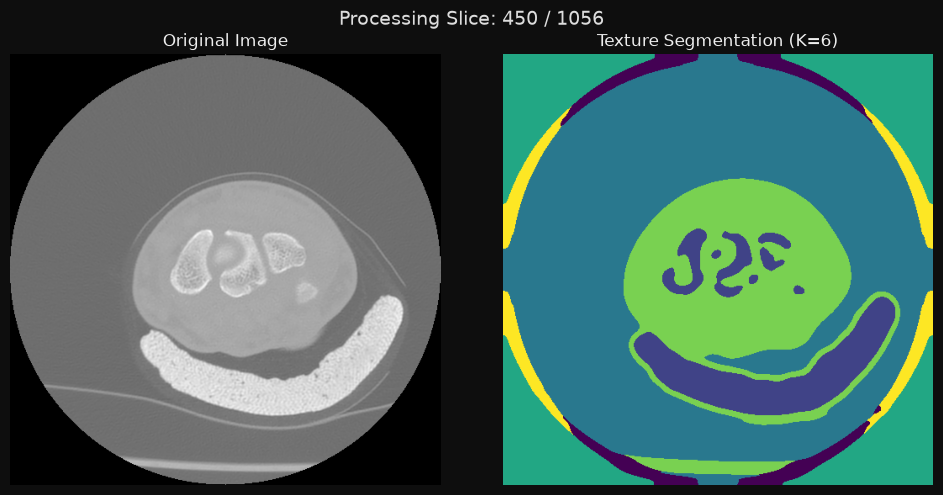

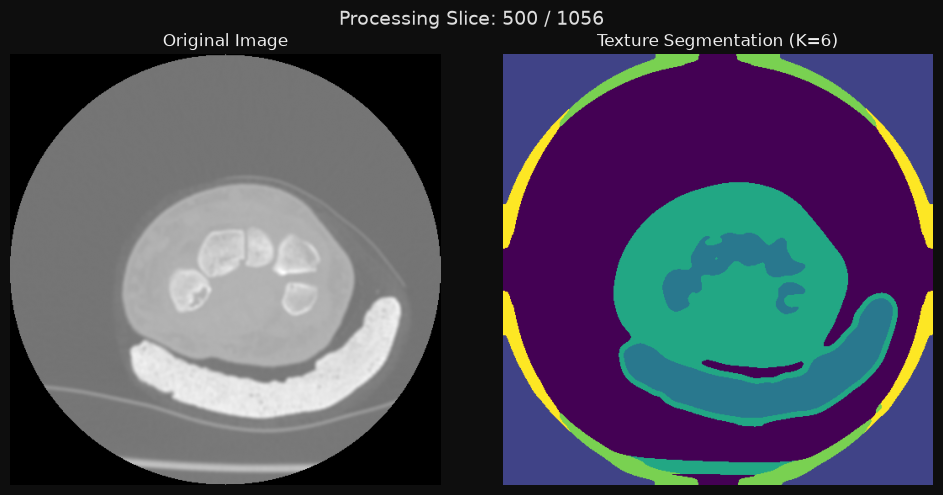

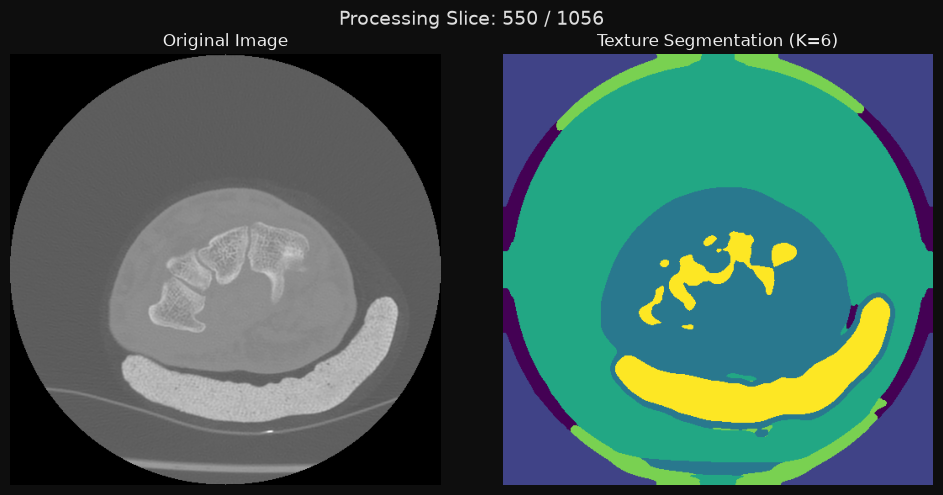

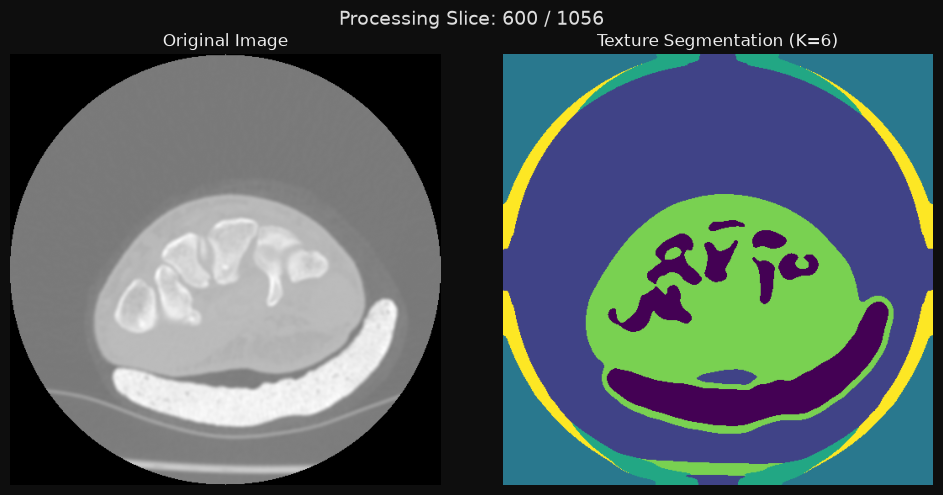

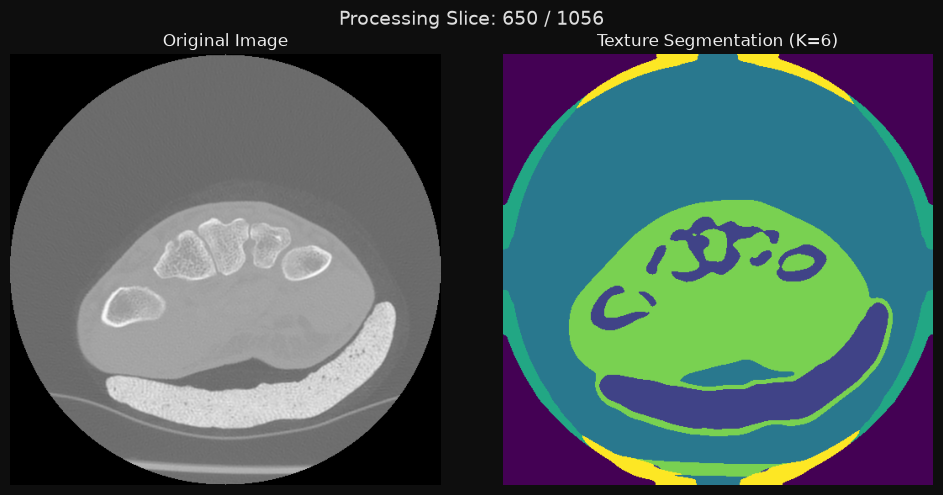

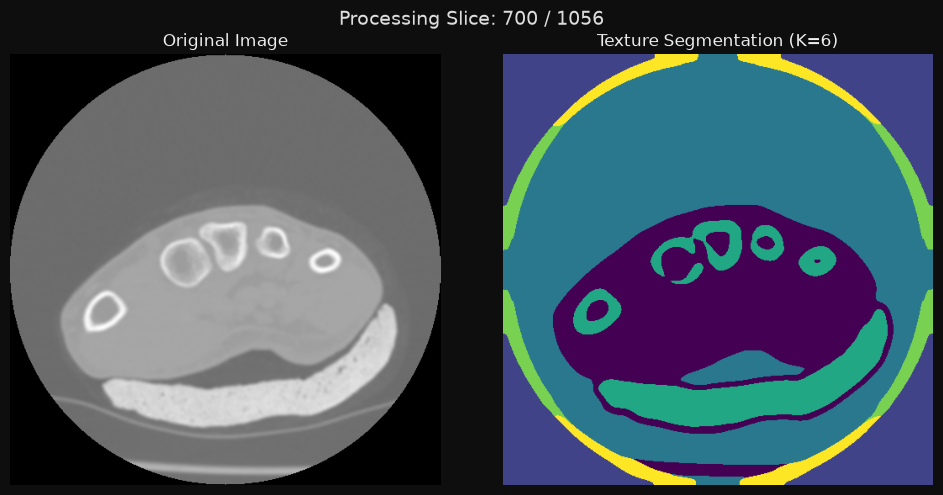

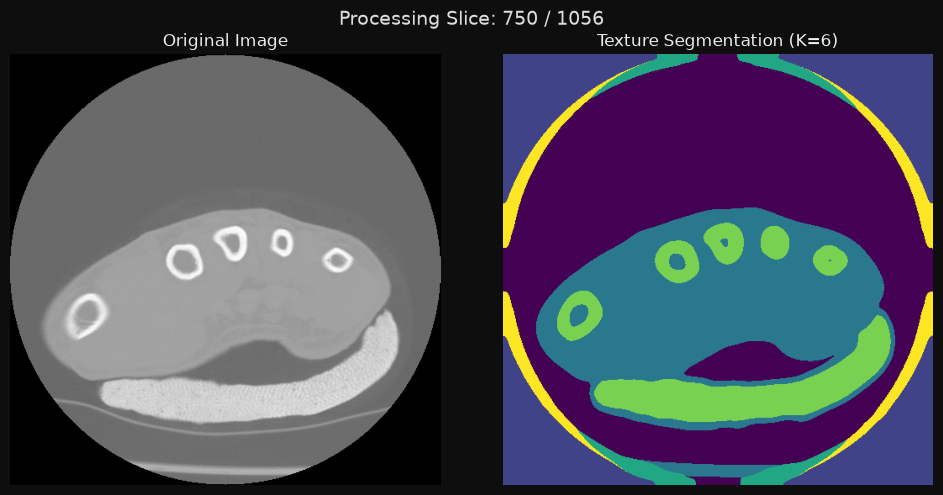

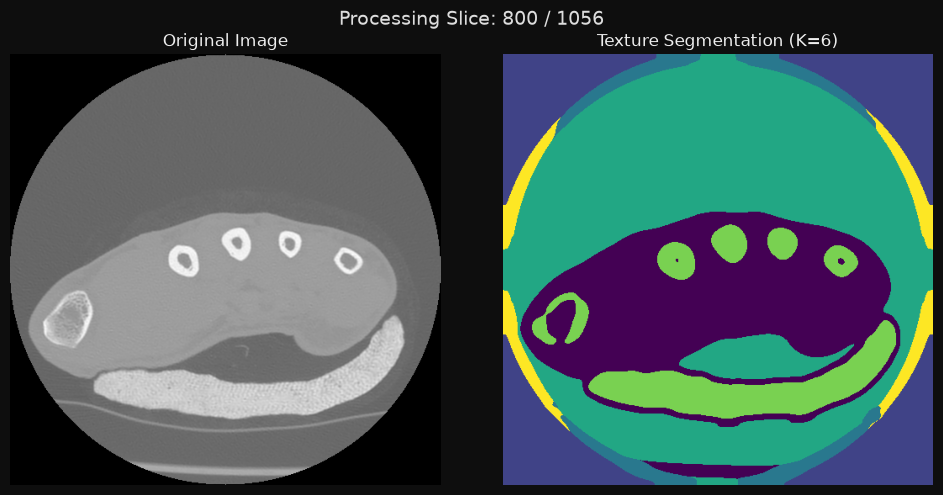

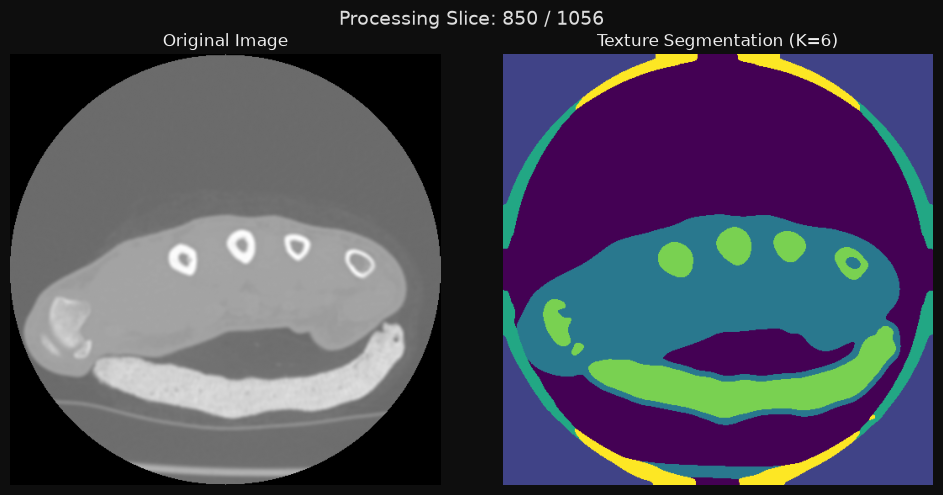

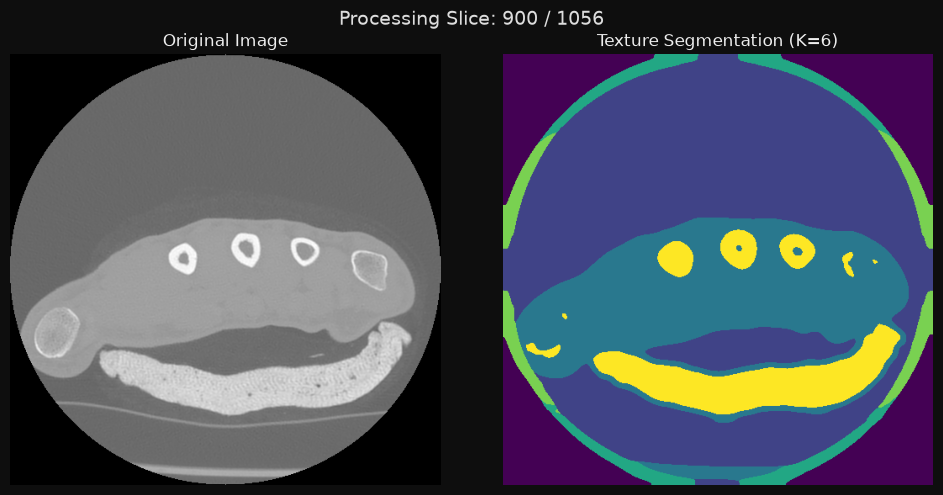

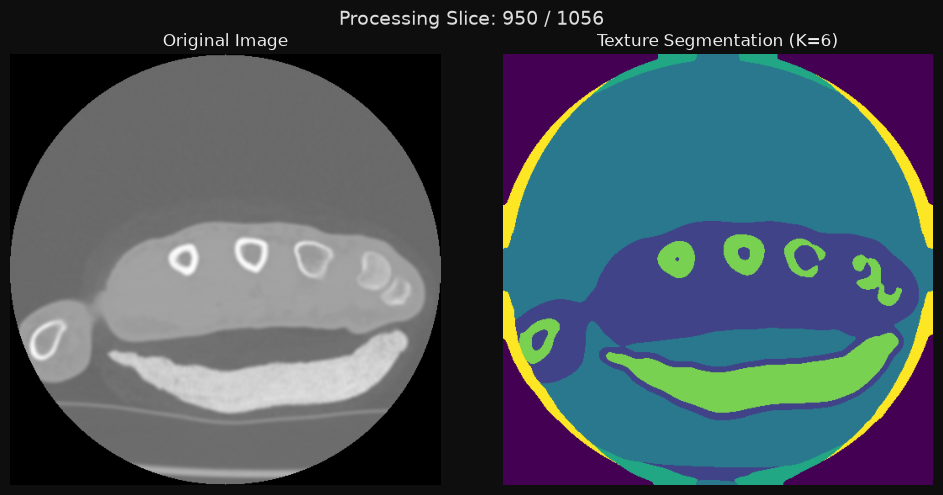

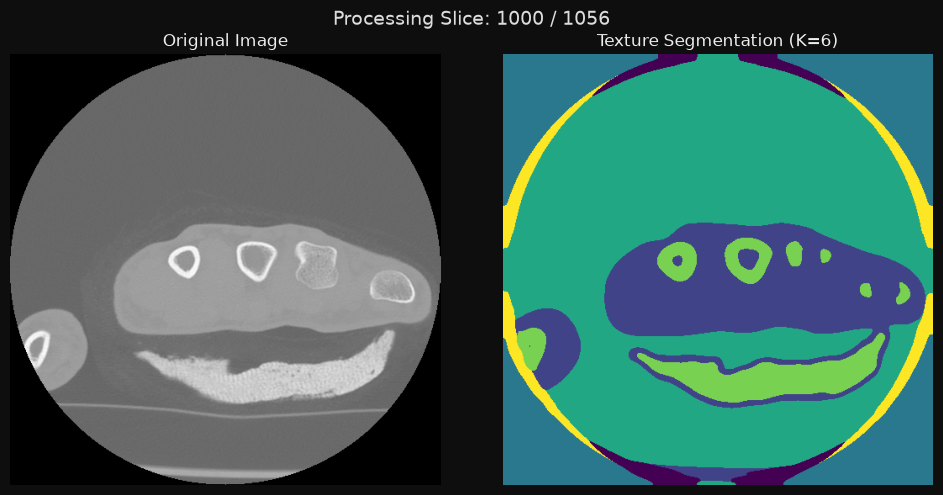

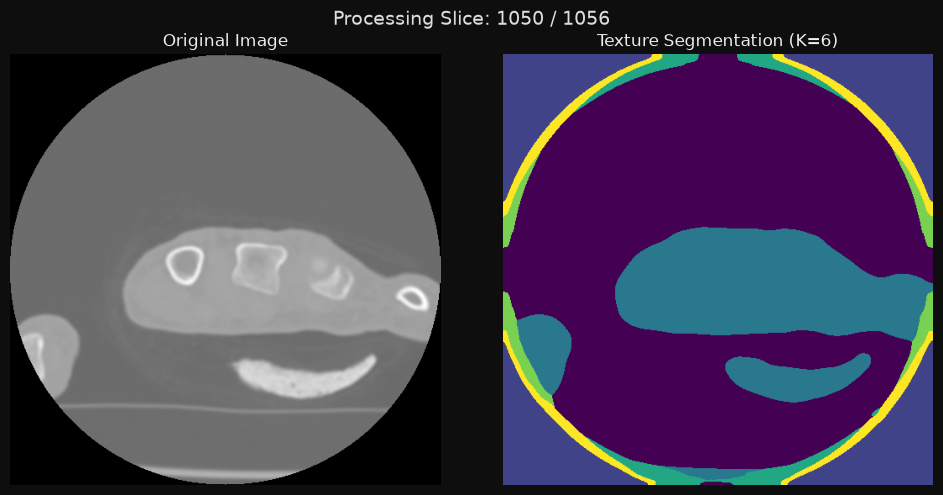

In [67]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Define parameters
K = 6
escalas = [1.5, 3.0, 4.5]
window_size = 15

# Loop through the volume, processing every 50th slice
for slice_idx in range(0, len(volume), 50):
    img_original = volume[slice_idx]
    img_8u = cv2.normalize(img_original, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

    # Build the Filter Bank (3 Scales x 8 Filters = 24 Dimensions)
    filters = []
    for scale in escalas:
        for theta in np.arange(0, np.pi, np.pi / 7):
            kern = cv2.getGaborKernel((21, 21), 2.0 * scale, theta, 5.0 * scale, 0.5, 0, ktype=cv2.CV_32F)
            filters.append(kern)
        
        gauss_kern = cv2.getGaussianKernel(21, 2.0 * scale)
        gauss_kern_2d = (gauss_kern @ gauss_kern.T).astype(np.float32)
        log_kern = cv2.Laplacian(gauss_kern_2d, cv2.CV_32F)
        filters.append(log_kern)

    # Feature Extraction per Pixel (Moving Average Window)
    features = []
    for kern in filters:
        filtered_img = cv2.filter2D(img_8u, cv2.CV_32F, kern)
        magnitude = np.abs(filtered_img)
        local_mean = cv2.blur(magnitude, (window_size, window_size))
        features.append(local_mean)

    # Format and Normalize Data
    X_spatial = np.stack(features, axis=-1)
    X_vectors = X_spatial.reshape(-1, 24)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_vectors)

    # K-Means Clustering (OpenCV)
    Z = np.float32(X_scaled)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
    _, label, _ = cv2.kmeans(Z, K, None, criteria, 10, cv2.KMEANS_PP_CENTERS)

    # Reshape and Visualize Segmentation
    segmentation_map = label.reshape(img_8u.shape)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(f"Processing Slice: {slice_idx} / {len(volume)-1}", fontsize=14)
    
    ax1.imshow(img_8u, cmap="gray")
    ax1.set_title("Original Image")
    ax1.axis("off")

    ax2.imshow(segmentation_map, cmap="viridis")
    ax2.set_title(f"Texture Segmentation (K={K})")
    ax2.axis("off")

    plt.tight_layout()
    plt.show()